# Análise Exploratória de Dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Leitura do DataFrame e separação das features e métricas

In [ ]:

df = pd.read_csv("../data/kikle_challenge_clean.csv")

# Métricas de performance que vamos analisar
performance_metrics = ["ctr", "roas", "engagement_rate", "conversions", "avg_watch_time_s"]

# Features acionáveis (o anunciante pode mudar)
bool_features     = ["has_hook", "has_face", "has_cta", "has_subtitle"]
continuous_feats  = ["video_duration_s", "music_voice_ratio"]
cat_actionable    = ["format", "text_density"]

# Contexto (fixo por campanha)
context_features  = ["platform", "category", "objective", "target_audience_age", "is_retargeting"]

all_actionable = bool_features + continuous_feats + cat_actionable

## Análise de Correlações e o Impacto dos Atributos criativos

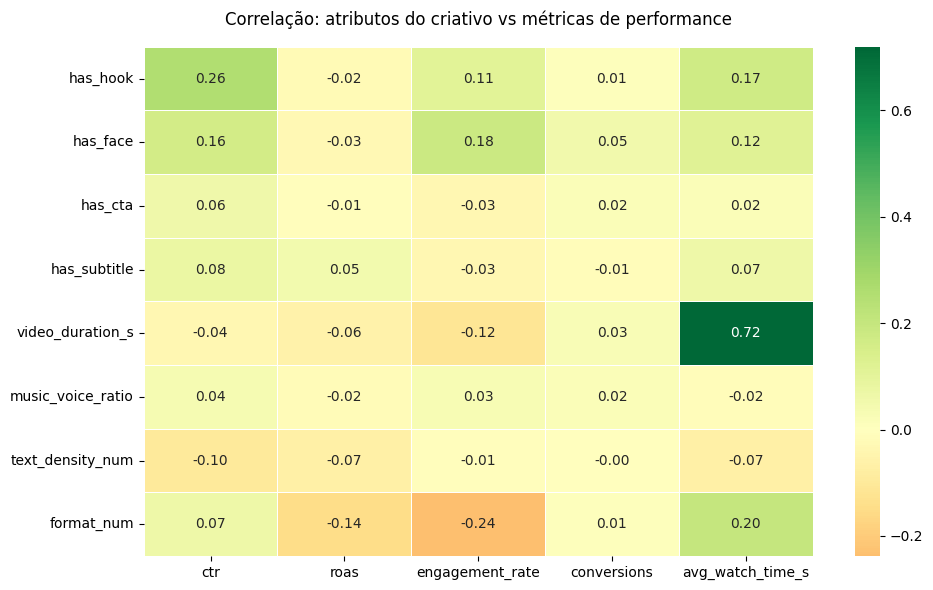

In [3]:
corr_cols = all_actionable + ["text_density_num", "format_num"] + performance_metrics

# Encode ordinal para correlação
df_corr = df.copy()
df_corr["text_density_num"] = df_corr["text_density"].map({"low": 0, "medium": 1, "high": 2})
df_corr["format_num"]       = df_corr["format"].map({"vertical": 0, "quadrado": 1, "horizontal": 2})
df_corr[bool_features]      = df_corr[bool_features].apply(
    lambda col: col.map({'True': 1, 'False': 0, 'unknown': 0, True: 1, False: 0}).astype(int)
)

corr_matrix = df_corr[
    bool_features + continuous_feats + ["text_density_num", "format_num"] + performance_metrics
].corr()

# Filtra só a parte que importa: features acionáveis vs métricas
corr_subset = corr_matrix.loc[
    bool_features + continuous_feats + ["text_density_num", "format_num"],
    performance_metrics
]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    corr_subset,
    annot=True, fmt=".2f",
    cmap="RdYlGn", center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Correlação: atributos do criativo vs métricas de performance", pad=16)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Heatmap — Principais Sinais

A correlação entre `video_duration_s` e `avg_watch_time_s` (0.72) é alta e esperada, uma vez que vídeos mais longos tendem a acumular maior tempo de visualização. No entanto, trata-se de uma relação estrutural, que não gera insight acionável.

Os sinais mais relevantes observados foram:

- Correlação negativa entre `format_num` e `engagement_rate` (-0.24), indicando que formatos mais horizontais tendem a reduzir o engajamento.
- Correlação negativa entre `text_density_num` e `CTR` (-0.10), sugerindo que maior densidade de texto pode prejudicar a taxa de clique.

Esses resultados reforçam a importância de decisões de formato e composição visual no desempenho criativo.

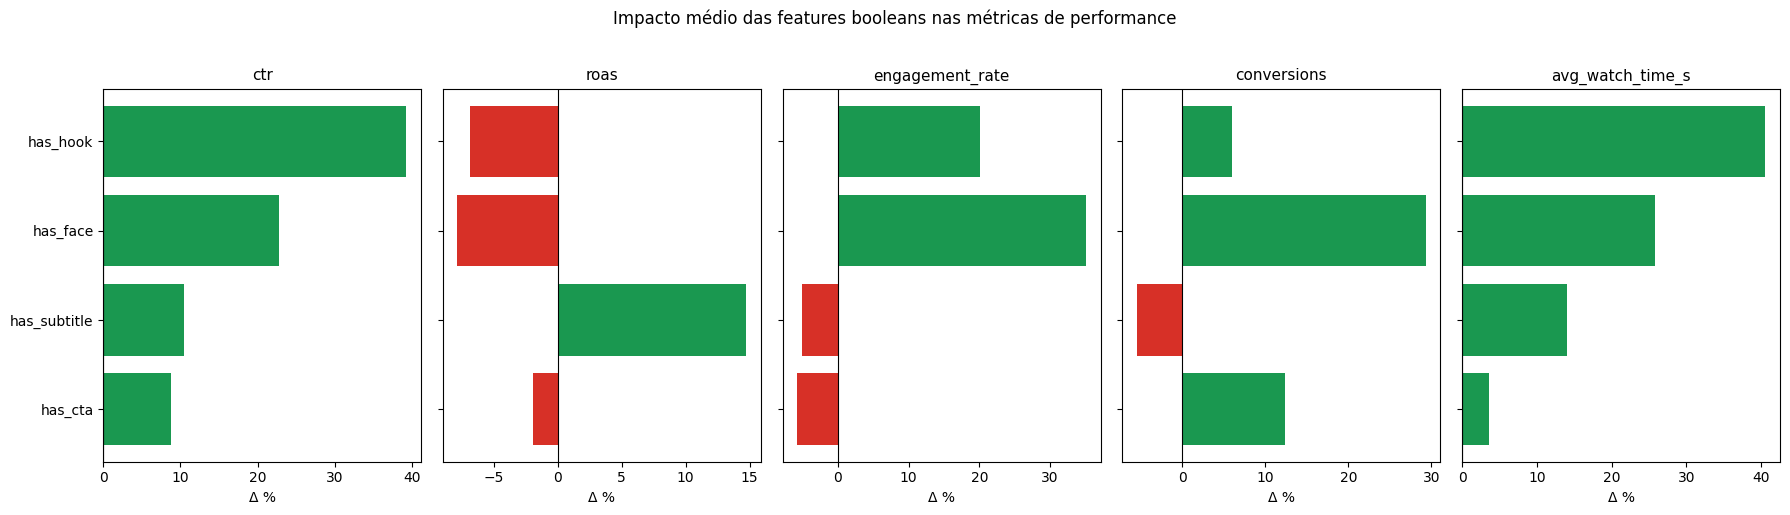

metric        avg_watch_time_s  conversions   ctr  engagement_rate  roas
feature                                                                 
has_cta                    3.6         12.4   8.8             -5.8  -1.9
has_face                  25.8         29.4  22.8             35.1  -7.8
has_hook                  40.5          6.0  39.2             20.1  -6.9
has_subtitle              14.0         -5.5  10.5             -5.1  14.8


In [4]:
delta_rows = []

for feat in bool_features:
    col = df_corr[feat]
    for metric in performance_metrics:
        mean_with    = df_corr.loc[col == 1, metric].mean()
        mean_without = df_corr.loc[col == 0, metric].mean()
        delta_pct    = (mean_with - mean_without) / mean_without * 100
        delta_rows.append({
            "feature": feat,
            "metric": metric,
            "mean_with": mean_with,
            "mean_without": mean_without,
            "delta_pct": delta_pct,
        })

delta_df = pd.DataFrame(delta_rows)

# Visualização
fig, axes = plt.subplots(1, len(performance_metrics), figsize=(18, 5), sharey=True)

for i, metric in enumerate(performance_metrics):
    data = delta_df[delta_df["metric"] == metric].sort_values("delta_pct")
    colors = ["#d73027" if v < 0 else "#1a9850" for v in data["delta_pct"]]
    axes[i].barh(data["feature"], data["delta_pct"], color=colors)
    axes[i].axvline(0, color="black", linewidth=0.8)
    axes[i].set_title(metric, fontsize=11)
    axes[i].set_xlabel("Δ %")

fig.suptitle("Impacto médio das features booleans nas métricas de performance", y=1.02)
plt.tight_layout()
plt.show()

print(delta_df.pivot(index="feature", columns="metric", values="delta_pct").round(1))

### Tabela de Deltas — Impacto dos Atributos Criativos

A análise de deltas evidencia o impacto direto de atributos criativos nas métricas de performance:

- **has_hook**  
  Apresenta o maior impacto positivo em métricas de atenção:
  - +39.2% em CTR  
  - +40.5% em tempo médio de visualização  
  Indica que capturar a atenção nos primeiros segundos é crítico.  
  No entanto, observa-se um impacto negativo em ROAS (-6.9%), o que sugere a necessidade de investigação adicional para entender se há efeito de segmentação ou trade-off entre atenção e conversão.

- **has_face**  
  Forte impacto em métricas de engajamento e ação:
  - +35.1% em engagement  
  - +29.4% em conversions  
  A presença de rostos humanos parece aumentar a conexão emocional e incentivar interações.

- **has_subtitle**  
  Único atributo com impacto positivo em ROAS:
  - +14.8%  
  Pode indicar maior efetividade em campanhas orientadas a retorno financeiro, possivelmente por melhorar a compreensão da mensagem.

- **has_cta**  
  Resultado contraintuitivo:
  - -5.8% em engagement  
  Sugere que chamadas para ação muito explícitas podem reduzir o engajamento em determinados contextos ou plataformas.

---

### Síntese

Os resultados indicam que atributos criativos têm impacto relevante e diferenciado nas métricas de performance, com destaque para:

- Hook como principal driver de atenção  
- Presença de rosto como fator de engajamento e conversão  
- Legendas como possível diferencial para retorno financeiro  
- Potencial trade-off entre elementos persuasivos e experiência do usuário


---

## Análise por Plataforma


### Performance média por plataforma

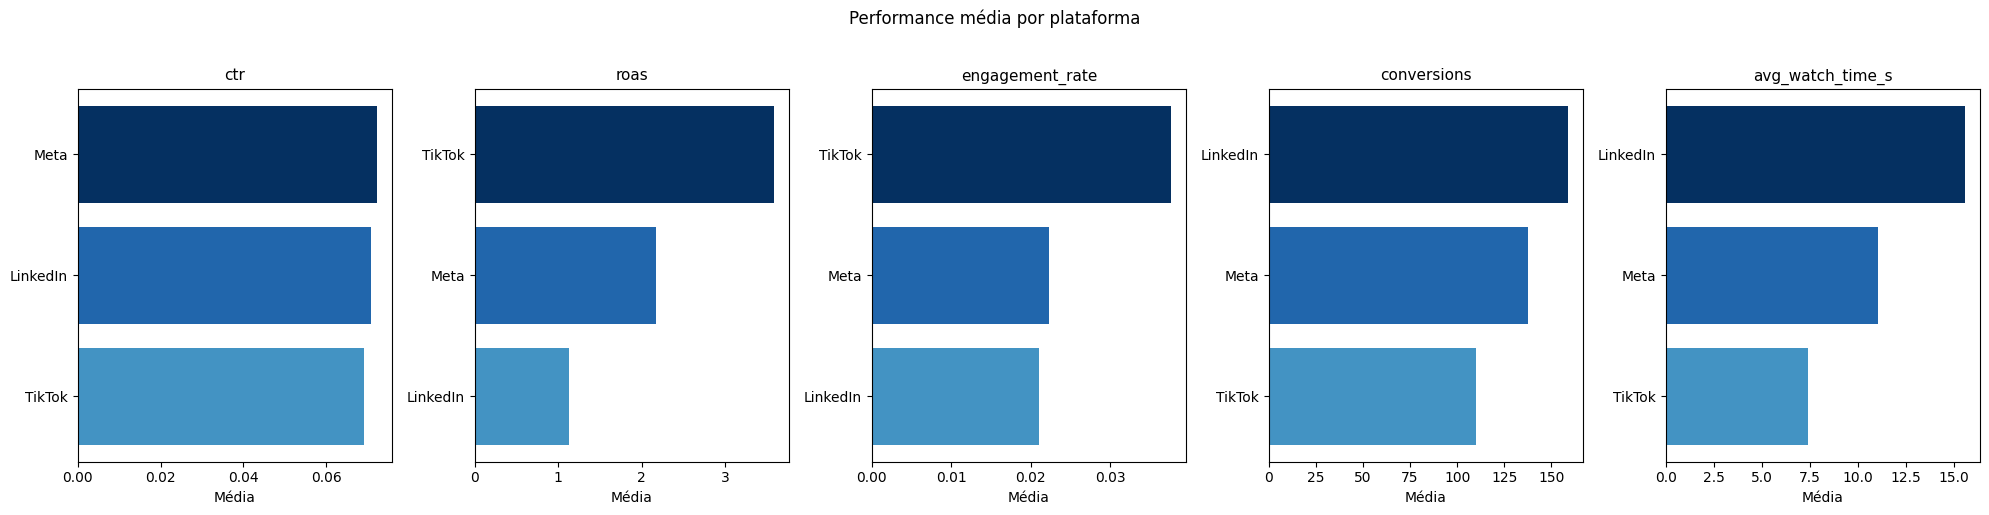

            ctr   roas  engagement_rate  conversions  avg_watch_time_s
platform                                                              
LinkedIn  0.071  1.128            0.021      158.892            15.560
Meta      0.072  2.176            0.022      137.564            11.027
TikTok    0.069  3.587            0.038      109.858             7.403


In [5]:
fig, axes = plt.subplots(1, len(performance_metrics), figsize=(20, 5))

for i, metric in enumerate(performance_metrics):
    data = df.groupby("platform")[metric].mean().sort_values(ascending=True)
    colors = ["#4393c3", "#2166ac", "#053061"][:len(data)]
    axes[i].barh(data.index, data.values, color=colors)
    axes[i].set_title(metric, fontsize=11)
    axes[i].set_xlabel("Média")

fig.suptitle("Performance média por plataforma", y=1.02)
plt.tight_layout()
plt.show()

print(df.groupby("platform")[performance_metrics].mean().round(3))



As plataformas apresentam perfis distintos de desempenho:

- **TikTok** lidera em ROAS (3.587) e engagement (0.038), sendo a plataforma com maior retorno financeiro e engajamento.
- **Meta** apresenta o maior CTR (0.072) e ROAS intermediário.
- **LinkedIn** se destaca com maior número médio de conversions (158.9) e maior tempo médio de visualização (15.5s), indicando um público menor, porém mais qualificado e engajado com o conteúdo.


### Heatmap por plataforma


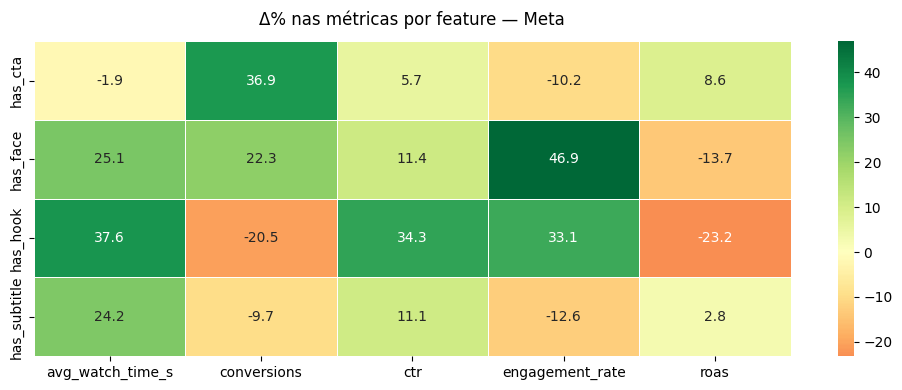

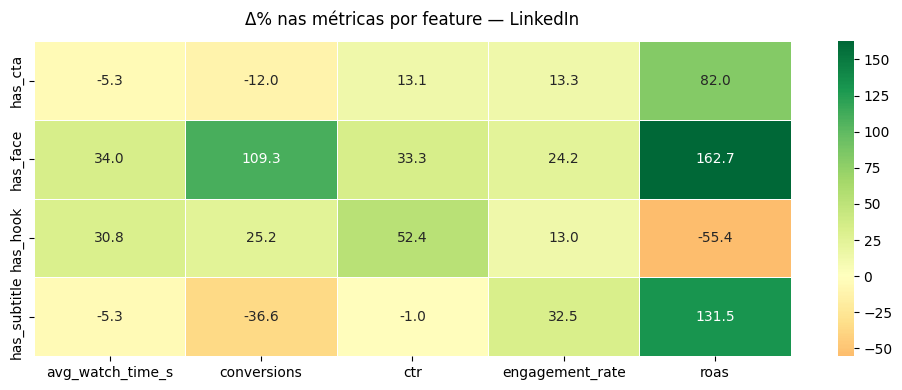

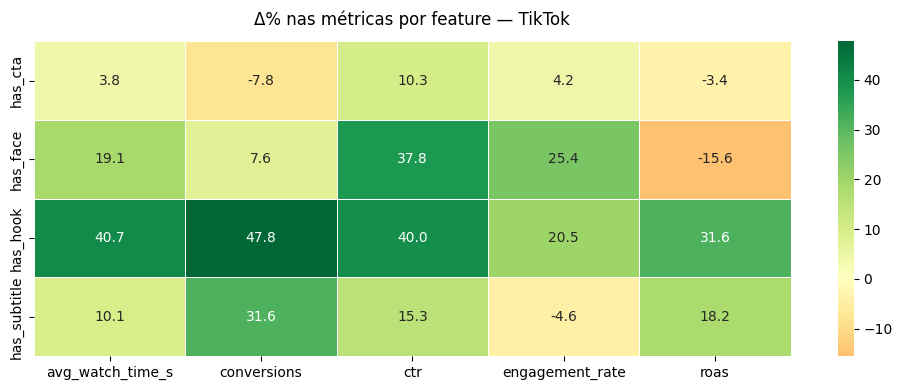

In [6]:
platforms = df["platform"].unique()
delta_platform_rows = []

for platform in platforms:
    df_plat = df_corr[df_corr["platform"] == platform]
    for feat in bool_features:
        col = df_plat[feat]
        for metric in performance_metrics:
            mean_with    = df_plat.loc[col == 1, metric].mean()
            mean_without = df_plat.loc[col == 0, metric].mean()
            if mean_without != 0 and not pd.isna(mean_without):
                delta_pct = (mean_with - mean_without) / mean_without * 100
            else:
                delta_pct = np.nan
            delta_platform_rows.append({
                "platform": platform,
                "feature":  feat,
                "metric":   metric,
                "delta_pct": delta_pct,
            })

delta_platform_df = pd.DataFrame(delta_platform_rows)

# Heatmap por plataforma — uma linha por feature, uma coluna por métrica
for platform in platforms:
    data = delta_platform_df[delta_platform_df["platform"] == platform]
    pivot = data.pivot(index="feature", columns="metric", values="delta_pct")
    
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(
        pivot, annot=True, fmt=".1f",
        cmap="RdYlGn", center=0,
        linewidths=0.5, ax=ax
    )
    ax.set_title(f"Δ% nas métricas por feature — {platform}", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


A análise por plataforma revela variações significativas no impacto dos atributos criativos:

- **has_face**
  - LinkedIn: impacto extremamente elevado (+109% em conversions e +162% em ROAS), sugerindo que rostos humanos aumentam confiança em contextos B2B.
  - TikTok: melhora CTR (+37.8%), mas reduz ROAS (-15.6%), indicando maior engajamento sem conversão proporcional.

- **has_hook**
  - TikTok: consistente em todas as métricas (+40% CTR, +47.8% conversions, +31.6% ROAS), sendo um dos principais drivers de performance.
  - LinkedIn: impacto negativo em ROAS (-55.4%), sugerindo que hooks mais agressivos podem não ser adequados para o público B2B.

- **has_subtitle**
  - LinkedIn: forte impacto positivo em ROAS (+131.5%), possivelmente devido ao consumo de conteúdo sem áudio em ambientes corporativos.
  - TikTok: efeito positivo mais moderado (+18.2%).

- **has_cta**
  - LinkedIn: impacto relevante em ROAS (+82%), indicando que chamadas diretas funcionam bem em um contexto orientado à decisão.

### Duração ideal por Plataforma

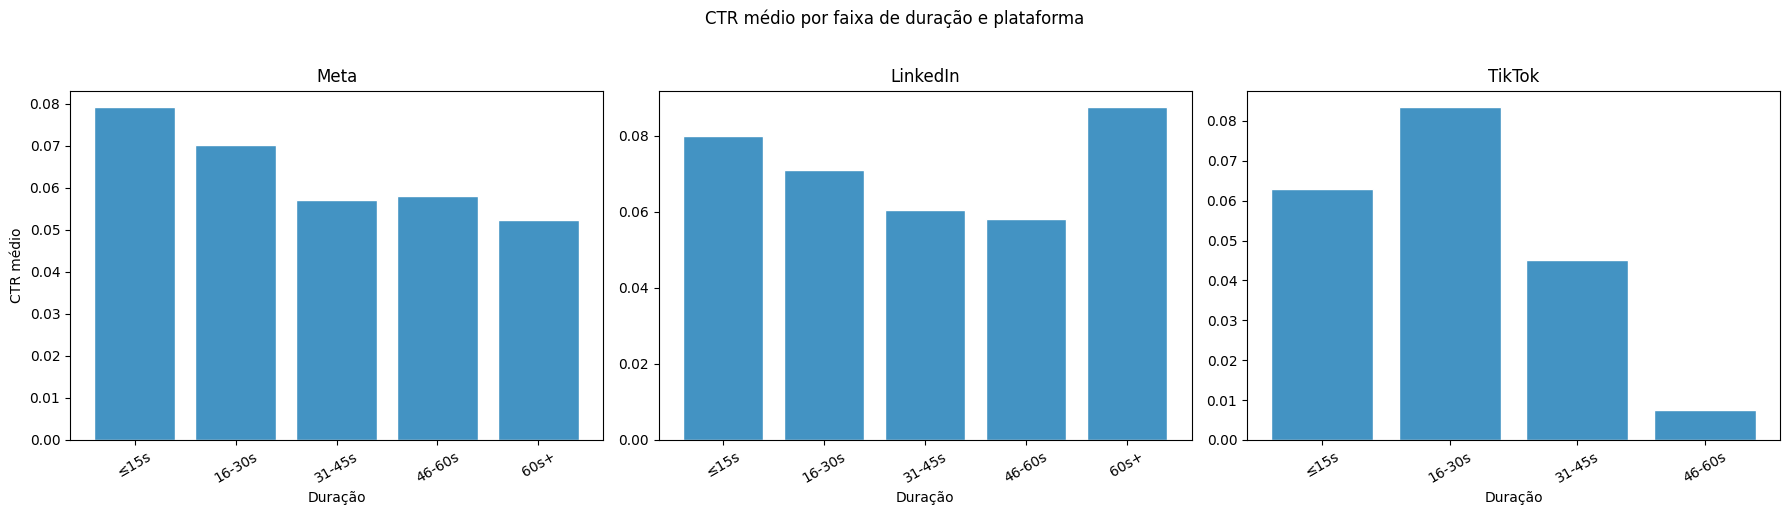

ctr   roas  engagement_rate  conversions  \
platform duration_bucket                                               
LinkedIn ≤15s             0.080  0.698            0.019       76.385   
         16-30s           0.071  0.706            0.022      131.667   
         31-45s           0.060  3.578            0.020      238.692   
         46-60s           0.058  0.670            0.012      738.000   
         60s+             0.087  0.020            0.022       54.333   
Meta     ≤15s             0.079  2.334            0.021      153.200   
         16-30s           0.070  2.077            0.025      142.221   
         31-45s           0.057  1.903            0.021       64.111   
         46-60s           0.058  1.963            0.014      100.222   
         60s+             0.052  2.292            0.016       44.000   
TikTok   ≤15s             0.063  3.262            0.039      103.364   
         16-30s           0.083  4.362            0.035      128.820   
         31-45s           0.045  1.610            0.028       26.750   
         46-60s           0.008  0.000            0.077        0.000   

                          avg_watch_time_s  
platform duration_bucket                    
LinkedIn ≤15s                        5.954  
         16-30s                     14.263  
         31-45s                     17.962  
         46-60s                     26.400  
         60s+                       58.000  
Meta     ≤15s                        5.913  
         16-30s                     11.948  
         31-45s                     20.778  
         46-60s                     20.067  
         60s+                       47.900  
TikTok   ≤15s                        5.085  
         16-30s                     10.667  
         31-45s                     18.375  
         46-60s                     19.400

In [8]:
# Cria faixas de duração
df_corr["duration_bucket"] = pd.cut(
    df_corr["video_duration_s"],
    bins=[0, 15, 30, 45, 60, np.inf],
    labels=["≤15s", "16-30s", "31-45s", "46-60s", "60s+"]
)

fig, axes = plt.subplots(1, len(platforms), figsize=(18, 5), sharey=False)

for i, platform in enumerate(platforms):
    df_plat = df_corr[df_corr["platform"] == platform]
    data = df_plat.groupby("duration_bucket", observed=True)["ctr"].mean()
    
    axes[i].bar(data.index, data.values, color="#4393c3", edgecolor="white")
    axes[i].set_title(platform, fontsize=12)
    axes[i].set_xlabel("Duração")
    axes[i].set_ylabel("CTR médio" if i == 0 else "")
    axes[i].tick_params(axis='x', rotation=30)

fig.suptitle("CTR médio por faixa de duração e plataforma", y=1.02)
plt.tight_layout()
plt.show()

# Tabela completa: duração × plataforma × métricas
display(df_corr.groupby(["platform", "duration_bucket"], observed=True)[performance_metrics].mean().round(3))

Os padrões de duração variam significativamente:

- **Meta e TikTok**
  - Vídeos curtos (≤15s e 16–30s) apresentam melhor desempenho em CTR.
  - Indicam preferência por conteúdo rápido e direto.

- **LinkedIn**
  - Vídeos mais longos (60s+) apresentam CTR elevado (0.087).
  - O público demonstra maior tolerância e interesse por conteúdos mais aprofundados.

- **TikTok**
  - Não há dados relevantes para vídeos de 60s+, o que é consistente com o formato da plataforma.

### Format e text_density por Plataforma

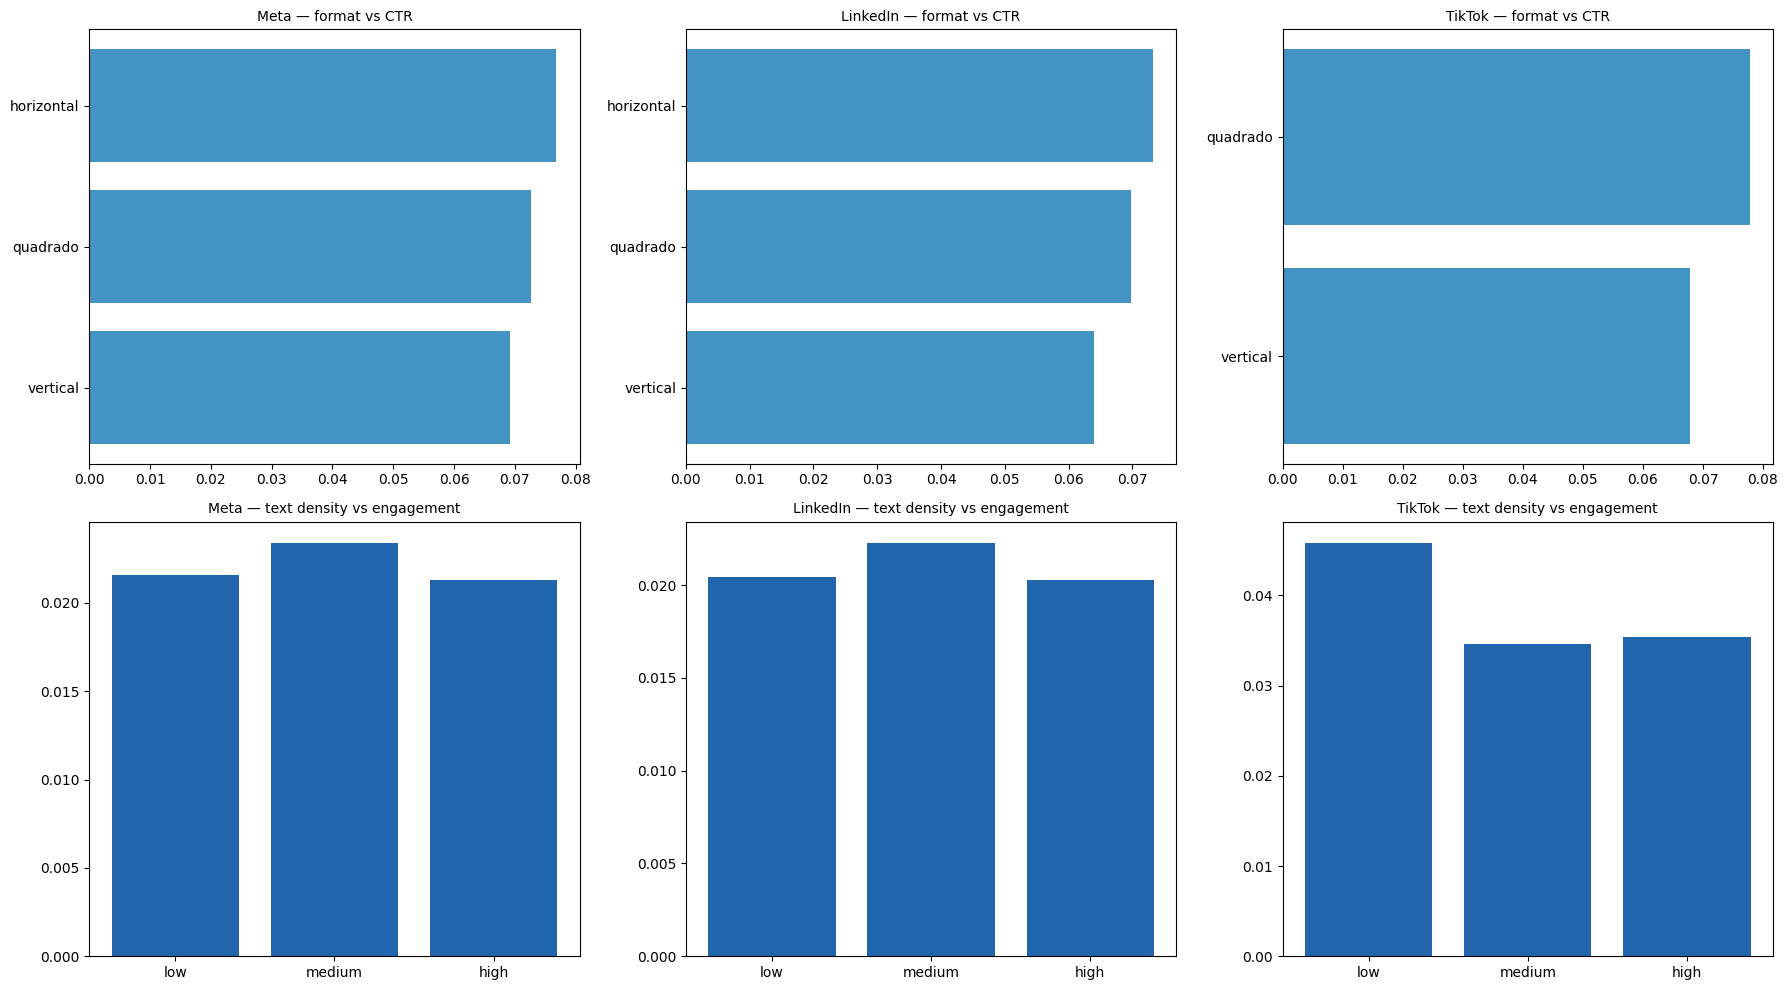

In [9]:
fig, axes = plt.subplots(2, len(platforms), figsize=(18, 10))

for i, platform in enumerate(platforms):
    df_plat = df_corr[df_corr["platform"] == platform]
    
    # Format vs CTR
    fmt_data = df_plat.groupby("format")["ctr"].mean().sort_values(ascending=True)
    axes[0, i].barh(fmt_data.index, fmt_data.values, color="#4393c3")
    axes[0, i].set_title(f"{platform} — format vs CTR", fontsize=10)
    
    # Text density vs engagement
    td_data = df_plat.groupby("text_density")["engagement_rate"].mean()
    td_data = td_data.reindex(["low", "medium", "high"])
    axes[1, i].bar(td_data.index, td_data.values, color="#2166ac")
    axes[1, i].set_title(f"{platform} — text density vs engagement", fontsize=10)

plt.tight_layout()
plt.show()

- **Format**
  - Apresenta impacto praticamente neutro no CTR em todas as plataformas.
  - Diferenças entre formatos são mínimas, indicando baixo poder explicativo isolado.

- **Text Density**
  - TikTok:
    - Conteúdos com baixa densidade de texto performam melhor (CTR ~0.047).
    - Performance reduz à medida que a densidade aumenta.
  - Meta e LinkedIn:
    - Menor sensibilidade à densidade de texto.
    - Impacto pouco relevante nessas plataformas.


### Síntese

A análise evidencia que o impacto dos atributos criativos é altamente dependente da plataforma:

- TikTok favorece conteúdo direto, com hook forte e baixa densidade de texto  
- LinkedIn valoriza confiança, clareza e profundidade (rostos, legendas e CTAs)  
- Meta apresenta comportamento intermediário  

Essas diferenças reforçam a necessidade de adaptação criativa específica por plataforma.

## Lookup

In [12]:
lookup_rows = []

# 1. Deltas das features booleans por plataforma
for platform in df["platform"].unique():
    df_plat = df_corr[df_corr["platform"] == platform]
    for feat in bool_features:
        col = df_plat[feat]
        for metric in performance_metrics:
            mean_with    = df_plat.loc[col == 1, metric].mean()
            mean_without = df_plat.loc[col == 0, metric].mean()
            if mean_without and not pd.isna(mean_without):
                delta_pct = (mean_with - mean_without) / mean_without * 100
            else:
                delta_pct = np.nan
            lookup_rows.append({
                "feature":       feat,
                "change":        f"{feat}=1",
                "segment_type":  "platform",
                "segment_value": platform,
                "metric":        metric,
                "delta_pct":     round(delta_pct, 1),
                "mean_with":     round(mean_with, 4),
                "mean_without":  round(mean_without, 4),
                "n_with":        int((col == 1).sum()),
                "n_without":     int((col == 0).sum()),
            })

# 2. Deltas das features booleans por faixa etária
for age in df["target_audience_age"].unique():
    df_age = df_corr[df_corr["target_audience_age"] == age]
    for feat in bool_features:
        col = df_age[feat]
        for metric in performance_metrics:
            mean_with    = df_age.loc[col == 1, metric].mean()
            mean_without = df_age.loc[col == 0, metric].mean()
            if mean_without and not pd.isna(mean_without):
                delta_pct = (mean_with - mean_without) / mean_without * 100
            else:
                delta_pct = np.nan
            lookup_rows.append({
                "feature":       feat,
                "change":        f"{feat}=1",
                "segment_type":  "target_audience_age",
                "segment_value": age,
                "metric":        metric,
                "delta_pct":     round(delta_pct, 1),
                "mean_with":     round(mean_with, 4),
                "mean_without":  round(mean_without, 4),
                "n_with":        int((col == 1).sum()),
                "n_without":     int((col == 0).sum()),
            })

# 3. Duração ideal por plataforma (delta entre faixa ótima e média geral)
for platform in df["platform"].unique():
    df_plat = df_corr[df_corr["platform"] == platform]
    for metric in performance_metrics:
        by_bucket = df_plat.groupby("duration_bucket", observed=True)[metric].mean()
        global_mean = df_plat[metric].mean()
        best_bucket = by_bucket.idxmax()
        best_mean   = by_bucket.max()
        delta_pct   = (best_mean - global_mean) / global_mean * 100 if global_mean else np.nan
        lookup_rows.append({
            "feature":       "video_duration_s",
            "change":        f"duration={best_bucket}",
            "segment_type":  "platform",
            "segment_value": platform,
            "metric":        metric,
            "delta_pct":     round(delta_pct, 1),
            "mean_with":     round(best_mean, 4),
            "mean_without":  round(global_mean, 4),
            "n_with":        int(df_plat[df_plat["duration_bucket"] == best_bucket].shape[0]),
            "n_without":     int(df_plat.shape[0]),
        })

# 4. Text density por plataforma
for platform in df["platform"].unique():
    df_plat = df_corr[df_corr["platform"] == platform]
    for metric in performance_metrics:
        by_td     = df_plat.groupby("text_density", observed=True)[metric].mean()
        global_mean = df_plat[metric].mean()
        best_td   = by_td.idxmax()
        best_mean = by_td.max()
        delta_pct = (best_mean - global_mean) / global_mean * 100 if global_mean else np.nan
        lookup_rows.append({
            "feature":       "text_density",
            "change":        f"text_density={best_td}",
            "segment_type":  "platform",
            "segment_value": platform,
            "metric":        metric,
            "delta_pct":     round(delta_pct, 1),
            "mean_with":     round(best_mean, 4),
            "mean_without":  round(global_mean, 4),
            "n_with":        int(df_plat[df_plat["text_density"] == best_td].shape[0]),
            "n_without":     int(df_plat.shape[0]),
        })

# 5. Format por plataforma
for platform in df["platform"].unique():
    df_plat = df_corr[df_corr["platform"] == platform]
    for metric in performance_metrics:
        by_fmt      = df_plat.groupby("format", observed=True)[metric].mean()
        global_mean = df_plat[metric].mean()
        best_fmt    = by_fmt.idxmax()
        best_mean   = by_fmt.max()
        delta_pct   = (best_mean - global_mean) / global_mean * 100 if global_mean else np.nan
        lookup_rows.append({
            "feature":       "format",
            "change":        f"format={best_fmt}",
            "segment_type":  "platform",
            "segment_value": platform,
            "metric":        metric,
            "delta_pct":     round(delta_pct, 1),
            "mean_with":     round(best_mean, 4),
            "mean_without":  round(global_mean, 4),
            "n_with":        int(df_plat[df_plat["format"] == best_fmt].shape[0]),
            "n_without":     int(df_plat.shape[0]),
        })

# Monta o DataFrame final
lookup_table = pd.DataFrame(lookup_rows)

# Filtra entradas com n_with pequeno demais para ser confiável
lookup_table = lookup_table[lookup_table["n_with"] >= 10].copy()

print(f"Lookup table: {len(lookup_table)} entradas")
print(lookup_table.head(10).to_string())

# Salva para usar no engine
lookup_table.to_csv("lookup_table.csv", index=False)
print("\nSalvo em lookup_table.csv")

Lookup table: 179 entradas
    feature      change segment_type segment_value            metric  delta_pct  mean_with  mean_without  n_with  n_without
0  has_hook  has_hook=1     platform          Meta               ctr       34.3     0.0821        0.0611     128        113
1  has_hook  has_hook=1     platform          Meta              roas      -23.2     1.9070        2.4815     128        113
2  has_hook  has_hook=1     platform          Meta   engagement_rate       33.1     0.0253        0.0190     128        113
3  has_hook  has_hook=1     platform          Meta       conversions      -20.5   122.7109      154.3894     128        113
4  has_hook  has_hook=1     platform          Meta  avg_watch_time_s       37.6    12.6484        9.1912     128        113
5  has_face  has_face=1     platform          Meta               ctr       11.4     0.0761        0.0683     123        118
6  has_face  has_face=1     platform          Meta              roas      -13.7     2.0200        2.3393 

## Visualizações para time de Marketing

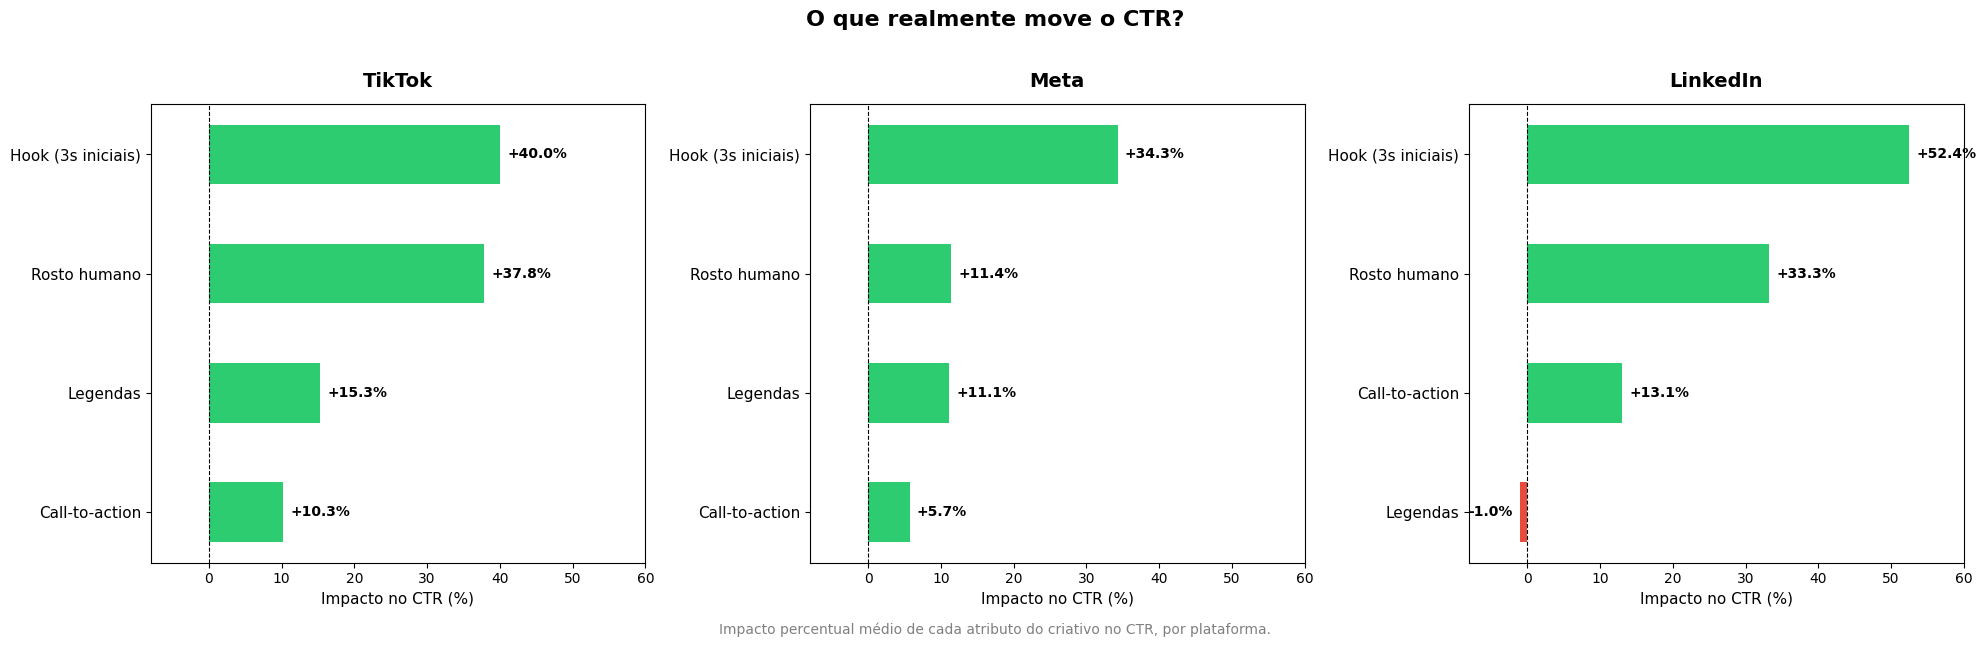

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))  # removeu sharey=True

platforms = ["TikTok", "Meta", "LinkedIn"]
colors_pos = "#2ecc71"
colors_neg = "#e74c3c"

label_map = {
    "has_hook": "Hook (3s iniciais)",
    "has_face": "Rosto humano",
    "has_cta": "Call-to-action",
    "has_subtitle": "Legendas"
}

for i, platform in enumerate(platforms):
    data = delta_platform_df[
        (delta_platform_df["platform"] == platform) &
        (delta_platform_df["metric"] == "ctr")
    ].sort_values("delta_pct", ascending=True)

    data = data.copy()
    data["label"] = data["feature"].map(label_map)

    colors = [colors_neg if v < 0 else colors_pos for v in data["delta_pct"]]
    bars = axes[i].barh(data["label"], data["delta_pct"], color=colors, height=0.5)
    axes[i].axvline(0, color="black", linewidth=0.8, linestyle="--")
    axes[i].set_title(platform, fontsize=14, fontweight="bold", pad=12)
    axes[i].set_xlabel("Impacto no CTR (%)", fontsize=11)
    axes[i].tick_params(axis="y", labelsize=11)

    for bar, val in zip(bars, data["delta_pct"]):
        x = bar.get_width()
        axes[i].text(
            x + (1 if x >= 0 else -1), bar.get_y() + bar.get_height() / 2,
            f"{val:+.1f}%", va="center",
            ha="left" if x >= 0 else "right",
            fontsize=10, fontweight="bold"
        )
# Pega o limite máximo absoluto entre todos os subplots e aplica igual
for ax in axes:
    ax.set_xlim(-8, 60)

fig.suptitle("O que realmente move o CTR?", fontsize=16, fontweight="bold", y=1.02)
fig.text(0.5, -0.02,
         "Impacto percentual médio de cada atributo do criativo no CTR, por plataforma.",
         ha="center", fontsize=10, color="gray")
plt.tight_layout()
plt.savefig("viz1_ctr_por_plataforma.png", dpi=150, bbox_inches="tight")
plt.show()

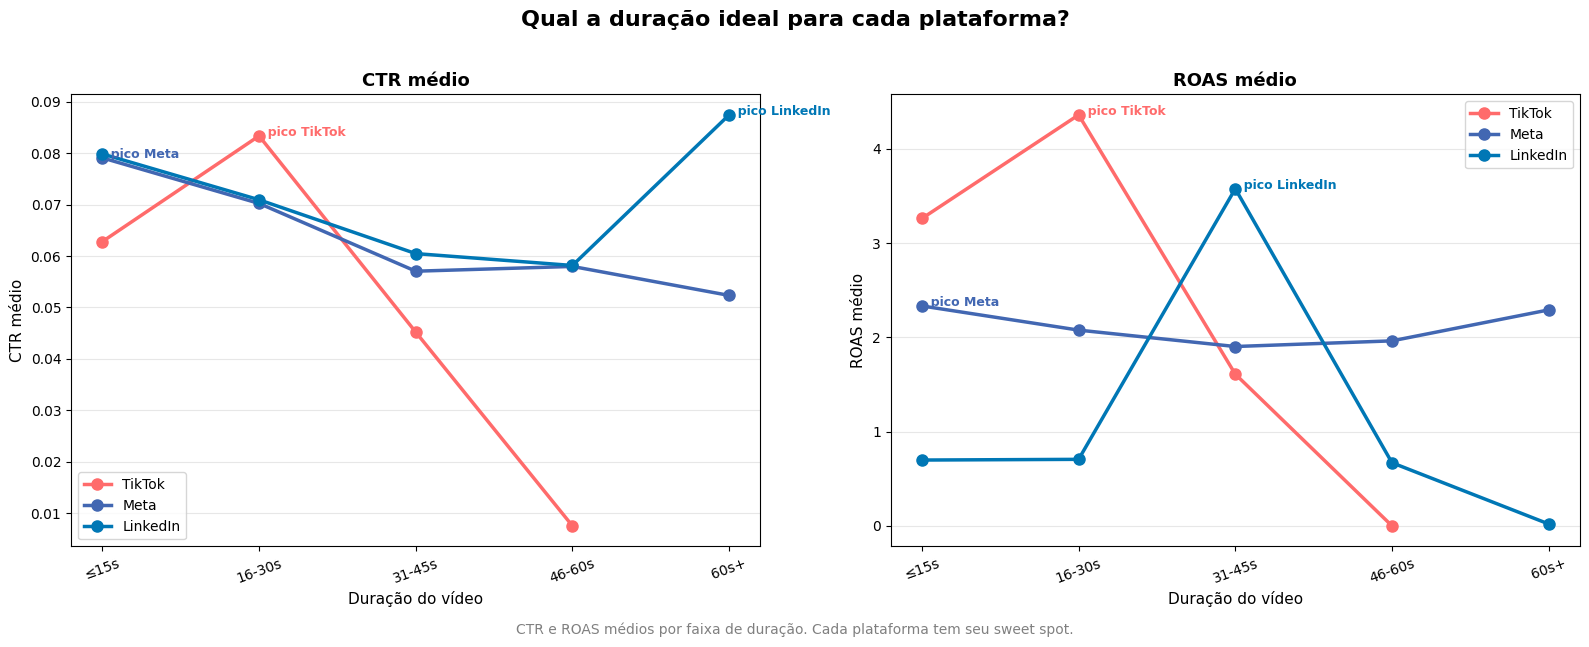

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics_viz2  = ["ctr", "roas"]
titles_viz2   = ["CTR médio", "ROAS médio"]
platform_colors = {"TikTok": "#ff6b6b", "Meta": "#4267B2", "LinkedIn": "#0077B5"}
duration_order  = ["≤15s", "16-30s", "31-45s", "46-60s", "60s+"]

for j, (metric, title) in enumerate(zip(metrics_viz2, titles_viz2)):
    for platform, color in platform_colors.items():
        df_plat = df_corr[df_corr["platform"] == platform]
        data = (df_plat.groupby("duration_bucket", observed=True)[metric]
                .mean()
                .reindex(duration_order)
                .dropna())
        axes[j].plot(data.index, data.values, marker="o", label=platform,
                     color=color, linewidth=2.5, markersize=8)

    axes[j].set_title(title, fontsize=13, fontweight="bold")
    axes[j].set_xlabel("Duração do vídeo", fontsize=11)
    axes[j].set_ylabel(title, fontsize=11)
    axes[j].legend(fontsize=10)
    axes[j].tick_params(axis="x", rotation=20)
    axes[j].grid(axis="y", alpha=0.3)

    # Anota o pico de cada plataforma
    for platform, color in platform_colors.items():
        df_plat = df_corr[df_corr["platform"] == platform]
        data = (df_plat.groupby("duration_bucket", observed=True)[metric]
                .mean()
                .reindex(duration_order)
                .dropna())
        if len(data) > 0:
            peak_x = data.idxmax()
            peak_y = data.max()
            axes[j].annotate(f"  pico {platform}",
                             xy=(peak_x, peak_y),
                             fontsize=9, color=color, fontweight="bold")

fig.suptitle("Qual a duração ideal para cada plataforma?",
             fontsize=16, fontweight="bold", y=1.02)
fig.text(0.5, -0.02,
         "CTR e ROAS médios por faixa de duração. Cada plataforma tem seu sweet spot.",
         ha="center", fontsize=10, color="gray")
plt.tight_layout()
plt.savefig("viz2_duracao_ideal.png", dpi=150, bbox_inches="tight")
plt.show()

Deltas no klike_score por plataforma:
TikTok: {'has_hook': 17.29, 'has_face': 10.69, 'has_cta': 9.12, 'has_subtitle': 8.03}
Meta: {'has_hook': 17.86, 'has_face': 12.94, 'has_cta': 7.61, 'has_subtitle': 6.24}
LinkedIn: {'has_hook': 15.95, 'has_face': 13.11, 'has_cta': 8.77, 'has_subtitle': 3.58}


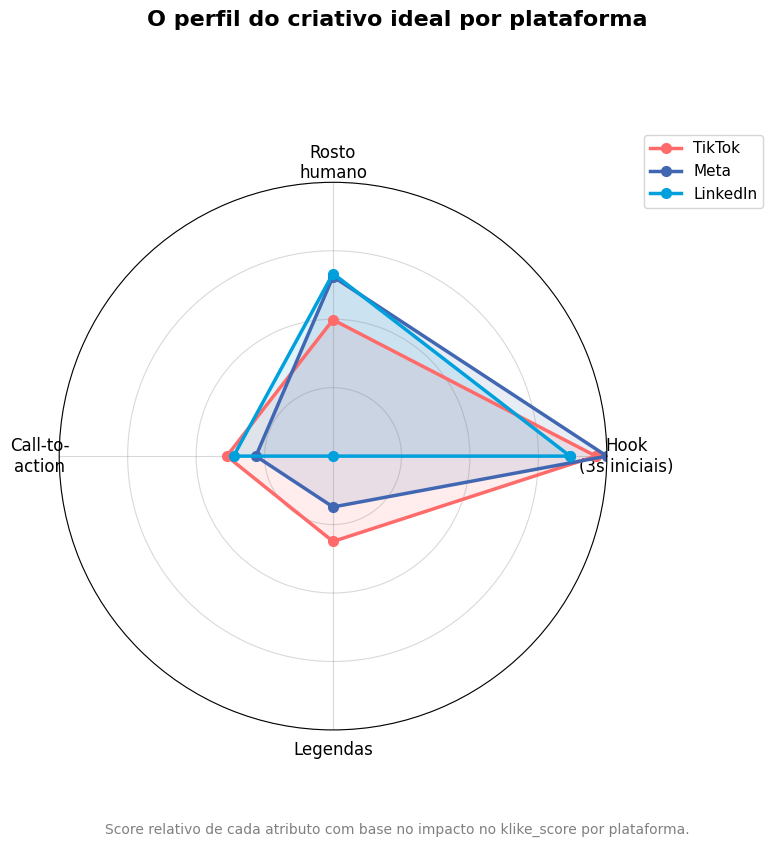

In [25]:
features_radar = ["has_hook", "has_face", "has_cta", "has_subtitle"]
labels_radar   = ["Hook\n(3s iniciais)", "Rosto\nhumano", "Call-to-\naction", "Legendas"]
platform_colors = {"TikTok": "#ff6b6b", "Meta": "#4267B2", "LinkedIn": "#00a0dc"}

# Delta no klike_score por feature × plataforma
radar_data = {}
for platform in platform_colors:
    df_plat = df_corr[df_corr["platform"] == platform]
    scores = []
    for feat in features_radar:
        col = df_plat[feat]
        mean_with    = df_plat.loc[col == 1, "klike_score"].mean()
        mean_without = df_plat.loc[col == 0, "klike_score"].mean()
        delta = mean_with - mean_without if not pd.isna(mean_without) else 0
        scores.append(delta)
    radar_data[platform] = scores

print("Deltas no klike_score por plataforma:")
for platform, scores in radar_data.items():
    print(f"{platform}: {dict(zip(features_radar, [round(s,2) for s in scores]))}")

# Normaliza para 0-1
all_vals = [v for scores in radar_data.values() for v in scores]
min_v, max_v = min(all_vals), max(all_vals)
for platform in radar_data:
    radar_data[platform] = [(v - min_v) / (max_v - min_v) for v in radar_data[platform]]

# Radar
N = len(features_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for platform, color in platform_colors.items():
    values = radar_data[platform] + radar_data[platform][:1]
    ax.plot(angles, values, color=color, linewidth=2.5,
            label=platform, marker="o", markersize=7)
    ax.fill(angles, values, color=color, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=12)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["", "", "", ""], fontsize=8)
ax.set_ylim(0, 1)
ax.grid(color="gray", alpha=0.3)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=11)

fig.suptitle("O perfil do criativo ideal por plataforma",
             fontsize=16, fontweight="bold", y=1.02)
fig.text(0.5, -0.01,
         "Score relativo de cada atributo com base no impacto no klike_score por plataforma.",
         ha="center", fontsize=10, color="gray")
plt.tight_layout()
plt.savefig("viz3_perfil_criativo.png", dpi=150, bbox_inches="tight")
plt.show()